In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# 自动定位项目根目录：notebook 位于 notes/ 下，向上一级即为项目根
cwd = os.getcwd()
if os.path.basename(cwd) == 'notes':
    os.chdir('..')
print('当前工作目录:', os.getcwd())

当前工作目录: d:\github\prediction


In [11]:
# ============================================================
# 方法一: 基线模型 —— 每小时历史均值预测
# ============================================================
# --- 1. 读取原始数据 (1141A 普陀站) + 预处理 + 80/15/5 分割 ---
import numpy as np
df_raw = pd.read_csv('data/ShanghaiPM_full.csv', na_values='NA')

# 预处理 (与 xg_boost(3) 一致: 时间轴补齐 → 插值 → pm_ave log → rolling)
WEATHER_COLS = ['DEWP', 'HUMI', 'PRES', 'TEMP', 'Iws', 'precipitation', 'Iprec']
df_raw['datetime'] = pd.to_datetime(
    {'year': df_raw['year'], 'month': df_raw['month'], 'day': df_raw['day'], 'hour': df_raw['hour']})
df_raw = df_raw.set_index('datetime').sort_index()
full_idx = pd.date_range(df_raw.index[0], df_raw.index[-1], freq='1h')
df_raw = df_raw.reindex(full_idx)
df_raw[WEATHER_COLS] = df_raw[WEATHER_COLS].interpolate(method='time').bfill().ffill()
pm_cols = ['PM_Jingan', 'PM_US Post', 'PM_Xuhui']
df_raw['pm_ave'] = df_raw[pm_cols].mean(axis=1)
df_raw['pm_ave'] = df_raw['pm_ave'].interpolate(method='time', limit=168)
df_raw = df_raw.dropna(subset=['pm_ave'])
df_raw['pm_ave'] = np.log1p(df_raw['pm_ave'])  # log 空间 (与 xg_boost 一致)
for c in WEATHER_COLS:
    df_raw[f'{c}_mean6'] = df_raw[c].rolling(6, min_periods=1).mean()
df_raw['pm_roll6_mean']  = df_raw['pm_ave'].rolling(6,  min_periods=1).mean()
df_raw['pm_roll6_std']   = df_raw['pm_ave'].rolling(6,  min_periods=1).std().fillna(0)
df_raw['pm_roll24_mean'] = df_raw['pm_ave'].rolling(24, min_periods=1).mean()
df_raw['pm_roll24_std']  = df_raw['pm_ave'].rolling(24, min_periods=1).std().fillna(0)

# 80/15/5 分割
n_total = len(df_raw)
n_train = int(n_total * 0.80)
n_val   = int(n_total * 0.15)
df_train = df_raw.iloc[:n_train].copy()
df_test  = df_raw.iloc[n_train + n_val:].copy()
print(f'总计: {n_total} | 训练集: {len(df_train)} | 测试集: {len(df_test)} (5%)')

# 基线预测: 用训练集每小时历史均值作为预测值
hourly_baseline = df_train.groupby(df_train.index.hour)['pm_ave'].mean()
df_prediction = pd.DataFrame({
    'timestamp': df_test.index,
    'predicted_pm_ave': df_test.index.hour.map(hourly_baseline)
})

# 把真实值并进 df_prediction (按行对齐，两者时间戳顺序一致)
df_prediction['actual_pm_ave'] = df_test['pm_ave'].values

# 逐条比对: 残差 = 真实值 - 预测值 (每个测试点单独算，不先做小时平均)
df_prediction['error'] = df_prediction['actual_pm_ave'] - df_prediction['predicted_pm_ave']

# 只保留有真实值的点参与 loss (三站全缺失的测试点无法评估)
mask = df_prediction['actual_pm_ave'].notna()
err = df_prediction.loc[mask, 'error']

# 均方误差 MSE = 残差平方的均值
mse = (err ** 2).mean()

print(f'有效比对样本数: {mask.sum()} / {len(df_prediction)}')
print(f'MSE = {mse:.2f}')
df_prediction.head(300)

总计: 70128 | 训练集: 56102 | 测试集: 3507 (5%)
有效比对样本数: 3507 / 3507
MSE = 0.59


,timestamp,predicted_pm_ave,actual_pm_ave,error
0,2023-08-07 21:00:00,3.283163,2.772589,-0.510574
1,2023-08-07 22:00:00,3.287821,2.772589,-0.515232
2,2023-08-07 23:00:00,3.302162,2.564949,-0.737212
3,2023-08-08 00:00:00,3.332909,2.708050,-0.624859
4,2023-08-08 01:00:00,3.350176,2.708050,-0.642126
...,...,...,...,...
295,2023-08-20 04:00:00,3.341687,2.890372,-0.451315
296,2023-08-20 05:00:00,3.343463,2.944439,-0.399024
297,2023-08-20 06:00:00,3.335802,2.639057,-0.696745
298,2023-08-20 07:00:00,3.318706,2.302585,-1.016121


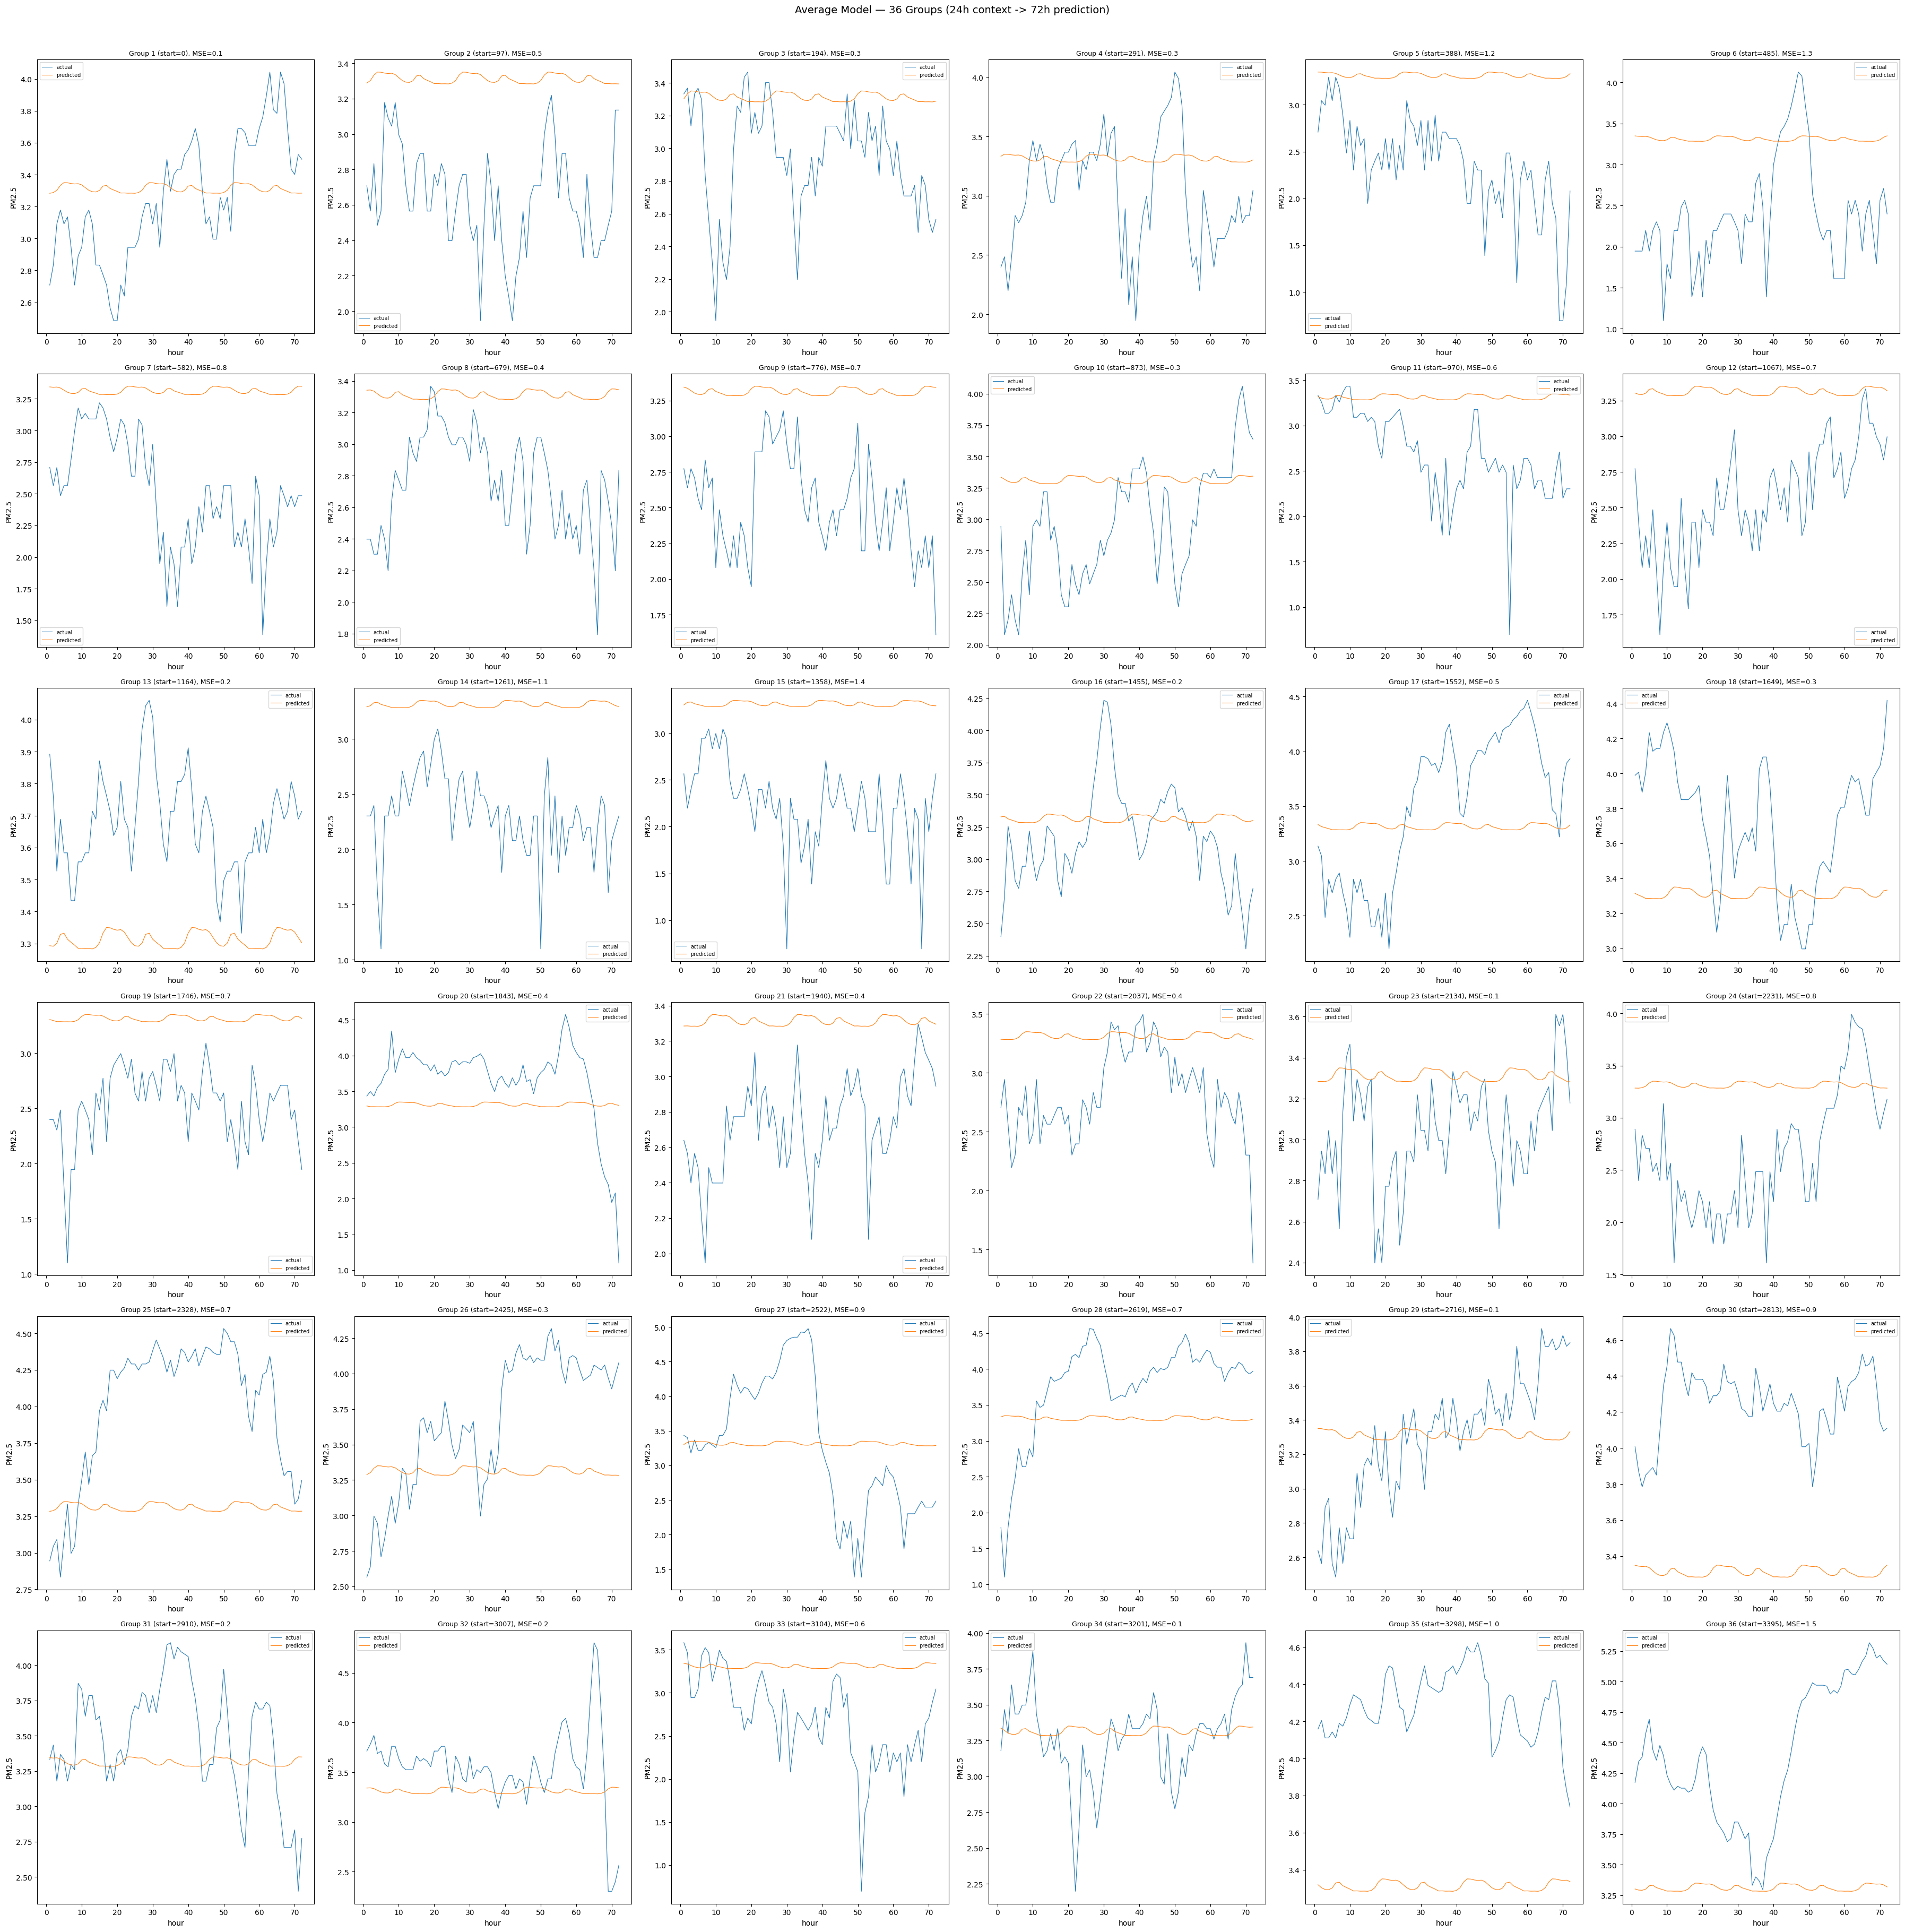


=== 36 组 MSE 汇总 ===
  Group  1: MSE = 0.15
  Group  2: MSE = 0.52
  Group  3: MSE = 0.25
  Group  4: MSE = 0.30
  Group  5: MSE = 1.20
  Group  6: MSE = 1.30
  Group  7: MSE = 0.83
  Group  8: MSE = 0.42
  Group  9: MSE = 0.73
  Group 10: MSE = 0.34
  Group 11: MSE = 0.62
  Group 12: MSE = 0.69
  Group 13: MSE = 0.15
  Group 14: MSE = 1.13
  Group 15: MSE = 1.40
  Group 16: MSE = 0.17
  Group 17: MSE = 0.46
  Group 18: MSE = 0.29
  Group 19: MSE = 0.72
  Group 20: MSE = 0.45
  Group 21: MSE = 0.42
  Group 22: MSE = 0.40
  Group 23: MSE = 0.14
  Group 24: MSE = 0.78
  Group 25: MSE = 0.68
  Group 26: MSE = 0.33
  Group 27: MSE = 0.94
  Group 28: MSE = 0.66
  Group 29: MSE = 0.13
  Group 30: MSE = 0.91
  Group 31: MSE = 0.19
  Group 32: MSE = 0.22
  Group 33: MSE = 0.64
  Group 34: MSE = 0.09
  Group 35: MSE = 0.98
  Group 36: MSE = 1.50

平均 MSE = 0.59


In [12]:
# ============================================================
# 36 组评估: 每组 24h 上下文 + 72h 预测 (基线模型)
# 基线模型直接用每小时历史均值, 无需多步预测
# ============================================================
import numpy as np

N_GROUPS = 36
N_CONTEXT = 24
N_PREDICT = 72
STRIDE = (len(df_test) - N_CONTEXT - N_PREDICT) // (N_GROUPS - 1)

pm_test = df_test['pm_ave'].values

all_mses = []
fig, axes = plt.subplots(6, 6, figsize=(36, 36))
axes = axes.flatten()

for g in range(N_GROUPS):
    start = g * STRIDE
    ctx_end = start + N_CONTEXT
    pred_end = ctx_end + N_PREDICT

    # 基线预测: 直接查表 hourly_baseline
    pred_hours = df_test.index[ctx_end:pred_end].hour
    preds = pred_hours.map(hourly_baseline).values
    actual = pm_test[ctx_end:pred_end]

    mse = ((preds - actual) ** 2).mean()
    all_mses.append(mse)

    ax = axes[g]
    hours = np.arange(1, N_PREDICT + 1)
    ax.plot(hours, actual, linewidth=0.8, label='actual')
    ax.plot(hours, preds, linewidth=0.8, label='predicted')
    ax.set_title(f'Group {g+1} (start={start}), MSE={mse:.1f}', fontsize=9)
    ax.legend(fontsize=7)
    ax.set_xlabel('hour')
    ax.set_ylabel('PM2.5')

plt.suptitle(f'Average Model — {N_GROUPS} Groups (24h context -> 72h prediction)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f'\n=== {N_GROUPS} 组 MSE 汇总 ===')
for g, mse in enumerate(all_mses):
    print(f'  Group {g+1:2d}: MSE = {mse:.2f}')
print(f'\n平均 MSE = {np.mean(all_mses):.2f}')